In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [60]:
df1 = pd.read_csv('2022NashikMandiWeather.csv')
df2 = pd.read_csv('2023NashikMandiWeather.csv')
df3 = pd.read_csv('2024NashikMandiWeather.csv')

In [61]:
df = df = pd.concat([df1, df2, df3], axis=0)

In [62]:
df

,date,Min_Price,Max_Price,Modal_Price,Market,Variety,WS2M,T2M,T2M_MAX,T2M_MIN,RH2M,QV2M,PRECTOTCORR,WS10M,PS
0,2022-03-01,1200.0,1952,1701.0,5,0,1.56,25.25,34.67,16.65,22.69,4.44,0.00,2.66,94.7
1,2022-03-01,500.0,2101,1775.0,5,2,1.56,25.25,34.67,16.65,22.69,4.44,0.00,2.66,94.7
2,2022-03-01,700.0,1941,1700.0,6,2,1.56,25.25,34.67,16.65,22.69,4.44,0.00,2.66,94.7
3,2022-03-01,500.0,2200,1750.0,7,2,1.56,25.25,34.67,16.65,22.69,4.44,0.00,2.66,94.7
4,2022-03-01,300.0,2060,1900.0,8,2,1.56,25.25,34.67,16.65,22.69,4.44,0.00,2.66,94.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,2025-05-31,650.0,2251,1450.0,14,0,4.98,26.05,30.64,23.37,82.03,18.18,0.24,6.71,94.0
1459,2025-05-31,600.0,1411,1100.0,15,0,4.98,26.05,30.64,23.37,82.03,18.18,0.24,6.71,94.0
1460,2025-05-31,600.0,1400,1100.0,15,0,4.98,26.05,30.64,23.37,82.03,18.18,0.24,6.71,94.0
1461,2025-05-31,1150.0,2105,1250.0,17,0,4.98,26.05,30.64,23.37,82.03,18.18,0.24,6.71,94.0


In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 3385 entries, 0 to 1462
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3385 non-null   str    
 1   Min_Price    3385 non-null   float64
 2   Max_Price    3385 non-null   int64  
 3   Modal_Price  3385 non-null   float64
 4   Market       3385 non-null   int64  
 5   Variety      3385 non-null   int64  
 6   WS2M         3385 non-null   float64
 7   T2M          3385 non-null   float64
 8   T2M_MAX      3385 non-null   float64
 9   T2M_MIN      3385 non-null   float64
 10  RH2M         3385 non-null   float64
 11  QV2M         3385 non-null   float64
 12  PRECTOTCORR  3385 non-null   float64
 13  WS10M        3385 non-null   float64
 14  PS           3385 non-null   float64
dtypes: float64(11), int64(3), str(1)
memory usage: 456.2 KB


In [64]:
df['date']=pd.to_datetime(df['date'])

In [65]:
df.info()

<class 'pandas.DataFrame'>
Index: 3385 entries, 0 to 1462
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3385 non-null   datetime64[us]
 1   Min_Price    3385 non-null   float64       
 2   Max_Price    3385 non-null   int64         
 3   Modal_Price  3385 non-null   float64       
 4   Market       3385 non-null   int64         
 5   Variety      3385 non-null   int64         
 6   WS2M         3385 non-null   float64       
 7   T2M          3385 non-null   float64       
 8   T2M_MAX      3385 non-null   float64       
 9   T2M_MIN      3385 non-null   float64       
 10  RH2M         3385 non-null   float64       
 11  QV2M         3385 non-null   float64       
 12  PRECTOTCORR  3385 non-null   float64       
 13  WS10M        3385 non-null   float64       
 14  PS           3385 non-null   float64       
dtypes: datetime64[us](1), float64(11), int64(3)
memory usage: 423.1 KB


In [66]:
#EDA

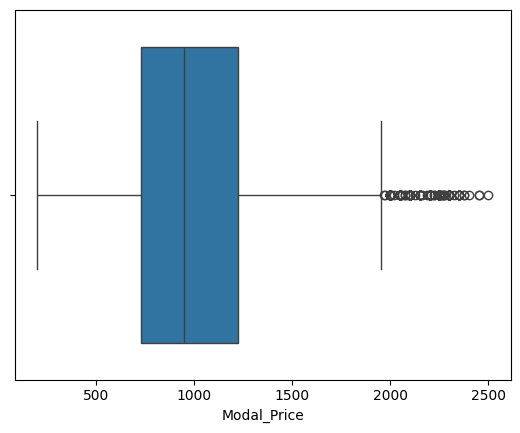

In [67]:
#on price data
sns.boxplot(x=df['Modal_Price'])
plt.show()

In [68]:
Q1 = df['Modal_Price'].quantile(0.25)
Q3 = df['Modal_Price'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['Modal_Price'] < lower) | (df['Modal_Price'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: -12.5
Upper bound: 1967.5
Number of outliers: 123


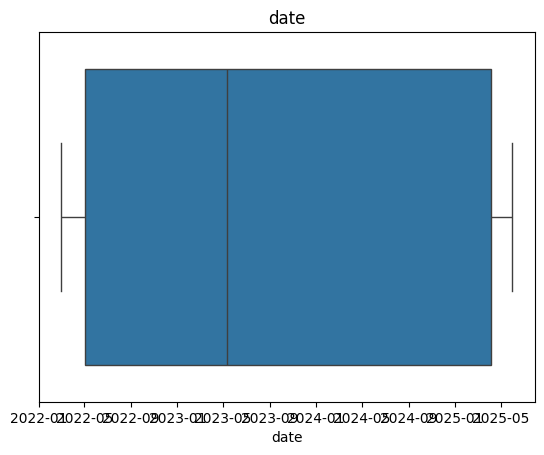

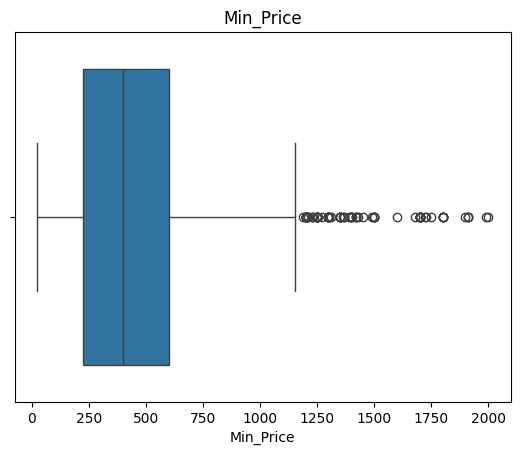

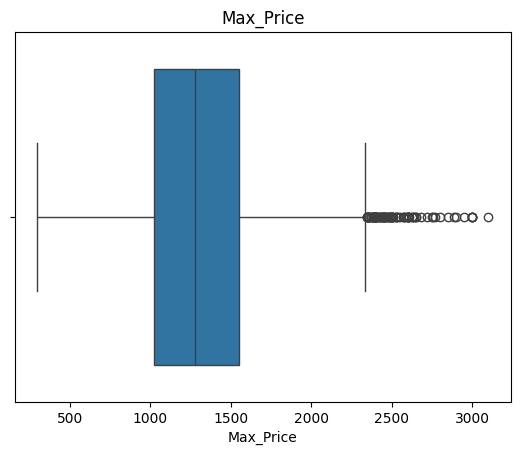

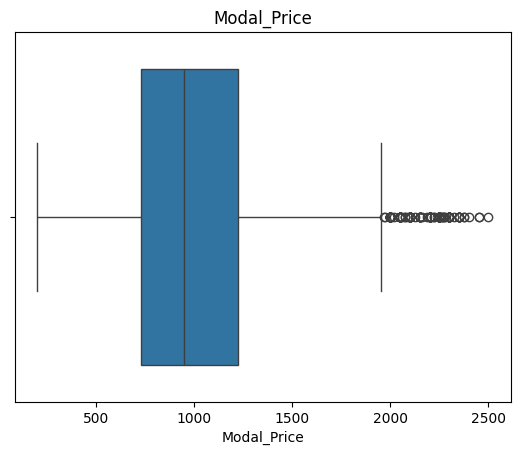

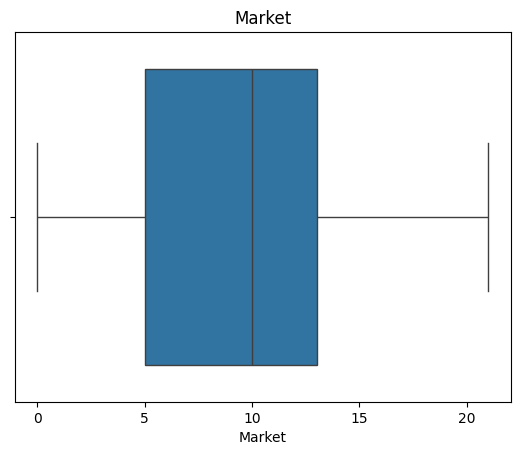

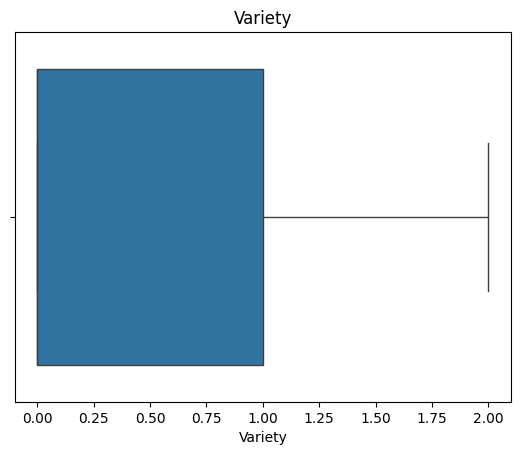

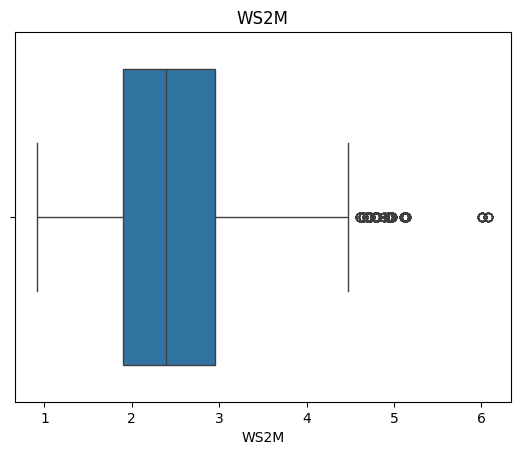

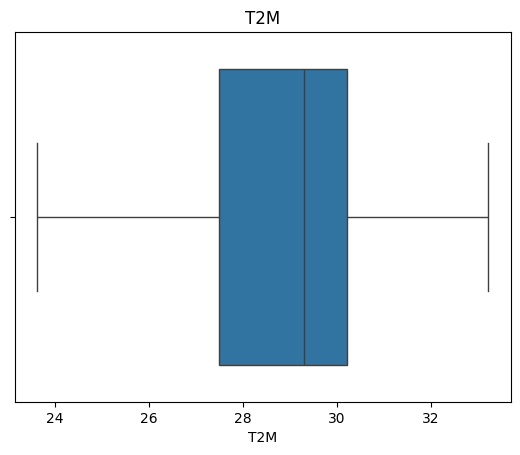

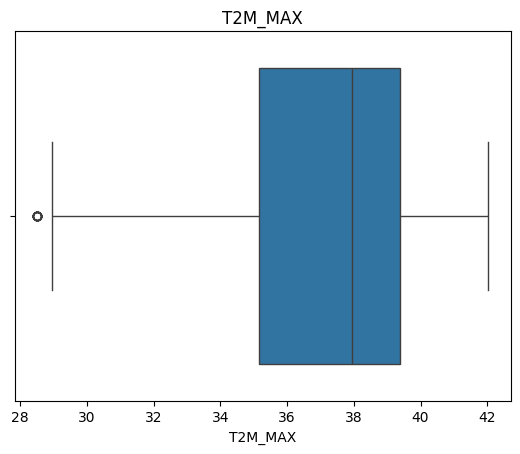

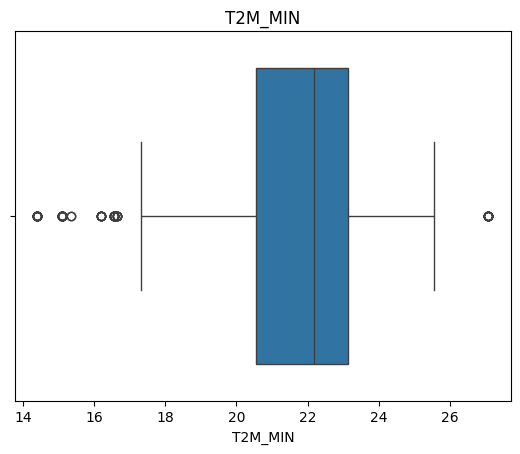

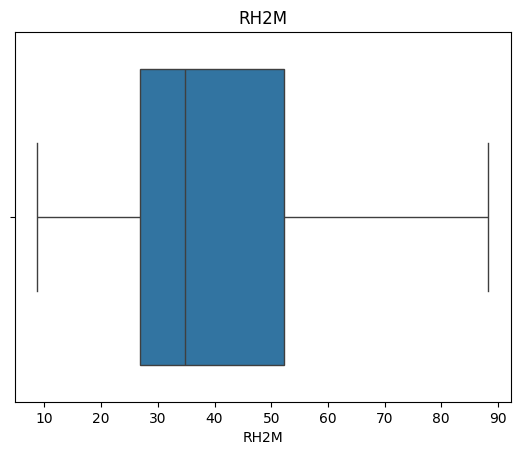

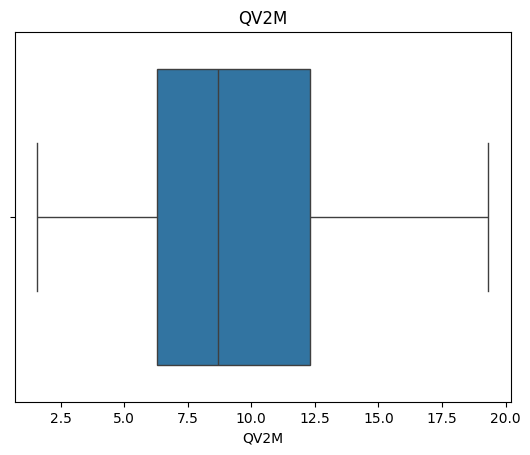

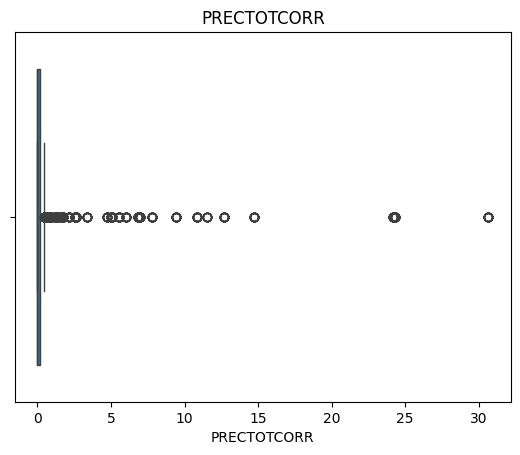

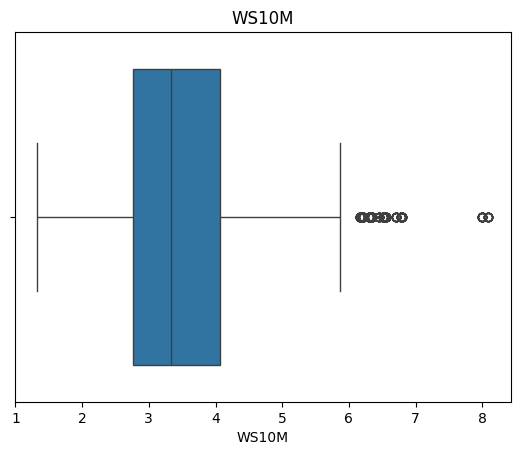

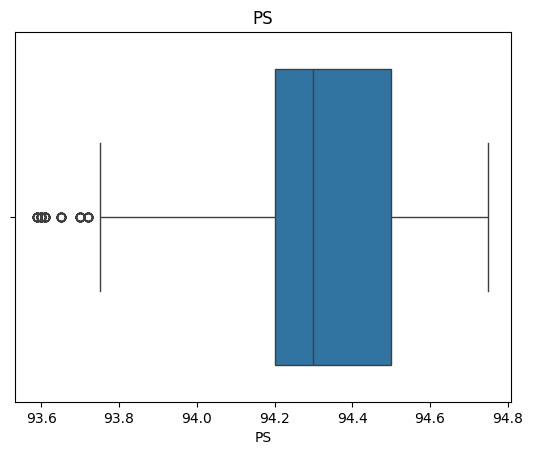

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns[:]:   # excluding DATE
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [70]:
#checking missing values
for col in df.columns[:]:
    print(col,"missing values:",df[col].isna().sum())

date missing values: 0
Min_Price missing values: 0
Max_Price missing values: 0
Modal_Price missing values: 0
Market missing values: 0
Variety missing values: 0
WS2M missing values: 0
T2M missing values: 0
T2M_MAX missing values: 0
T2M_MIN missing values: 0
RH2M missing values: 0
QV2M missing values: 0
PRECTOTCORR missing values: 0
WS10M missing values: 0
PS missing values: 0


In [71]:
outliers = -1

while True:
    Q1 = df['WS2M'].quantile(0.25)
    Q3 = df['WS2M'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df['WS2M'] < lower) | (df['WS2M'] > upper)]
    
    if len(outliers) == 0:
        break
    
    df = df[(df['WS2M'] >= lower) & (df['WS2M'] <= upper)]

In [72]:
df

,date,Min_Price,Max_Price,Modal_Price,Market,Variety,WS2M,T2M,T2M_MAX,T2M_MIN,RH2M,QV2M,PRECTOTCORR,WS10M,PS
0,2022-03-01,1200.0,1952,1701.00,5,0,1.56,25.25,34.67,16.65,22.69,4.44,0.0,2.66,94.70
1,2022-03-01,500.0,2101,1775.00,5,2,1.56,25.25,34.67,16.65,22.69,4.44,0.0,2.66,94.70
2,2022-03-01,700.0,1941,1700.00,6,2,1.56,25.25,34.67,16.65,22.69,4.44,0.0,2.66,94.70
3,2022-03-01,500.0,2200,1750.00,7,2,1.56,25.25,34.67,16.65,22.69,4.44,0.0,2.66,94.70
4,2022-03-01,300.0,2060,1900.00,8,2,1.56,25.25,34.67,16.65,22.69,4.44,0.0,2.66,94.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2025-04-30,600.0,1649,1200.00,5,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1426,2025-04-30,700.0,1410,1150.00,6,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1427,2025-04-30,600.0,2001,1100.00,7,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1428,2025-04-30,826.0,1355,1138.13,9,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24


In [73]:
Q1 = df['T2M'].quantile(0.25)
Q3 = df['T2M'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['T2M'] < lower) | (df['T2M'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: 23.064999999999994
Upper bound: 34.86500000000001
Number of outliers: 0


In [74]:
df = df[(df['T2M'] >= lower) & (df['T2M'] <= upper)]

In [75]:
Q1 = df['T2M_MAX'].quantile(0.25)
Q3 = df['T2M_MAX'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['T2M_MAX'] < lower) | (df['T2M_MAX'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: 29.460000000000004
Upper bound: 45.379999999999995
Number of outliers: 60


In [76]:
Q1 = df['T2M_MIN'].quantile(0.25)
Q3 = df['T2M_MIN'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['T2M_MIN'] < lower) | (df['T2M_MIN'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: 16.685
Upper bound: 26.805000000000003
Number of outliers: 113


In [77]:
df = df[(df['T2M_MIN'] >= lower) & (df['T2M_MIN'] <= upper)]

In [78]:
Q1 = df['RH2M'].quantile(0.25)
Q3 = df['RH2M'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['RH2M'] < lower) | (df['RH2M'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: -6.024999999999995
Upper bound: 82.095
Number of outliers: 83


In [79]:
Q1 = df['WS10M'].quantile(0.25)
Q3 = df['WS10M'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)
outliers = df[(df['WS10M'] < lower) | (df['WS10M'] > upper)]

print("Number of outliers:", len(outliers))

Lower bound: 0.835
Upper bound: 5.835
Number of outliers: 0


In [80]:
df

,date,Min_Price,Max_Price,Modal_Price,Market,Variety,WS2M,T2M,T2M_MAX,T2M_MIN,RH2M,QV2M,PRECTOTCORR,WS10M,PS
6,2022-03-02,300.0,1852,1500.00,17,2,2.04,25.80,34.92,17.68,25.65,5.35,0.0,3.17,94.65
7,2022-03-02,650.0,2070,1600.00,14,2,2.04,25.80,34.92,17.68,25.65,5.35,0.0,3.17,94.65
8,2022-03-02,500.0,2210,1701.00,12,1,2.04,25.80,34.92,17.68,25.65,5.35,0.0,3.17,94.65
9,2022-03-02,650.0,2200,1750.00,11,1,2.04,25.80,34.92,17.68,25.65,5.35,0.0,3.17,94.65
10,2022-03-02,100.0,2000,1650.00,10,2,2.04,25.80,34.92,17.68,25.65,5.35,0.0,3.17,94.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2025-04-30,600.0,1649,1200.00,5,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1426,2025-04-30,700.0,1410,1150.00,6,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1427,2025-04-30,600.0,2001,1100.00,7,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24
1428,2025-04-30,826.0,1355,1138.13,9,0,2.88,30.04,39.48,21.88,41.24,9.93,0.0,3.99,94.24


In [81]:
#some plots

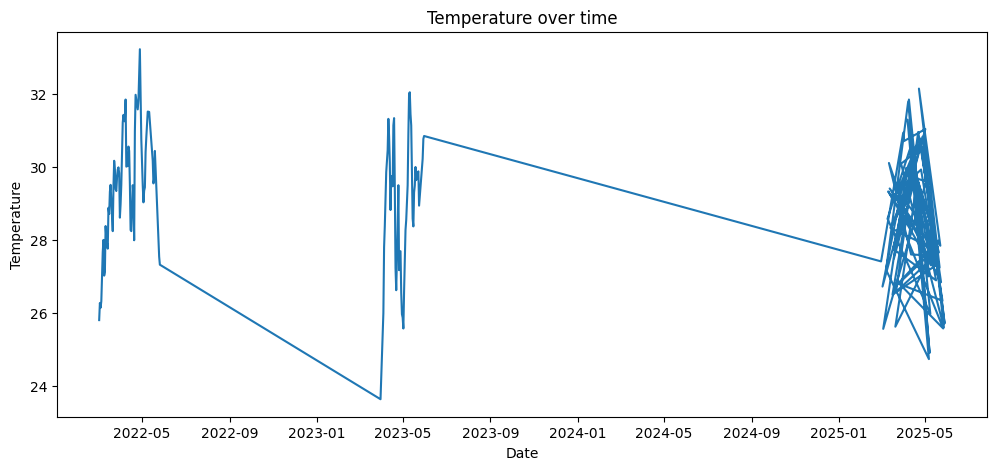

In [82]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['T2M'])
plt.title("Temperature over time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

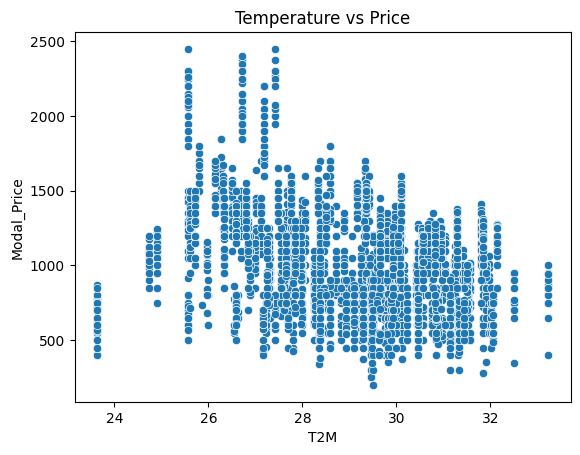

In [83]:
sns.scatterplot(x=df['T2M'], y=df['Modal_Price'])
plt.title("Temperature vs Price")
plt.show()

In [84]:
#feature engineering

In [85]:
lags = [1, 7, 14]

cols = ['Modal_Price', 'T2M', 'WS10M', 'PS']
#lagged feautures
for col in cols:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

In [86]:
windows = [1, 7, 14]
#rolling mean
for col in cols:
    for w in windows:
        df[f'{col}_roll_mean_{w}'] = df[col].rolling(window=w).mean()

In [87]:
df

,date,Min_Price,Max_Price,Modal_Price,Market,Variety,WS2M,T2M,T2M_MAX,T2M_MIN,...,Modal_Price_roll_mean_14,T2M_roll_mean_1,T2M_roll_mean_7,T2M_roll_mean_14,WS10M_roll_mean_1,WS10M_roll_mean_7,WS10M_roll_mean_14,PS_roll_mean_1,PS_roll_mean_7,PS_roll_mean_14
6,2022-03-02,300.0,1852,1500.00,17,2,2.04,25.80,34.92,17.68,...,NaN,25.80,NaN,NaN,3.17,NaN,NaN,94.65,NaN,NaN
7,2022-03-02,650.0,2070,1600.00,14,2,2.04,25.80,34.92,17.68,...,NaN,25.80,NaN,NaN,3.17,NaN,NaN,94.65,NaN,NaN
8,2022-03-02,500.0,2210,1701.00,12,1,2.04,25.80,34.92,17.68,...,NaN,25.80,NaN,NaN,3.17,NaN,NaN,94.65,NaN,NaN
9,2022-03-02,650.0,2200,1750.00,11,1,2.04,25.80,34.92,17.68,...,NaN,25.80,NaN,NaN,3.17,NaN,NaN,94.65,NaN,NaN
10,2022-03-02,100.0,2000,1650.00,10,2,2.04,25.80,34.92,17.68,...,NaN,25.80,NaN,NaN,3.17,NaN,NaN,94.65,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2025-04-30,600.0,1649,1200.00,5,0,2.88,30.04,39.48,21.88,...,1248.214286,30.04,26.328571,26.019286,3.99,5.412857,5.531429,94.24,93.691429,93.645714
1426,2025-04-30,700.0,1410,1150.00,6,0,2.88,30.04,39.48,21.88,...,1237.500000,30.04,26.947143,26.328571,3.99,5.175714,5.412857,94.24,93.782857,93.691429
1427,2025-04-30,600.0,2001,1100.00,7,0,2.88,30.04,39.48,21.88,...,1225.000000,30.04,27.565714,26.637857,3.99,4.938571,5.294286,94.24,93.874286,93.737143
1428,2025-04-30,826.0,1355,1138.13,9,0,2.88,30.04,39.48,21.88,...,1213.437857,30.04,28.184286,26.947143,3.99,4.701429,5.175714,94.24,93.965714,93.782857


In [88]:
df['WS10M_roll_mean_7'].isna().sum()

6

In [89]:
lag_roll_cols = [col for col in df.columns if 'lag' in col or 'roll_mean' in col]
for col in lag_roll_cols:
    df[col] = df[col].fillna(df[col].mean())

In [90]:
df['WS10M_roll_mean_7'].isna().sum()

0

In [91]:
df

,date,Min_Price,Max_Price,Modal_Price,Market,Variety,WS2M,T2M,T2M_MAX,T2M_MIN,...,Modal_Price_roll_mean_14,T2M_roll_mean_1,T2M_roll_mean_7,T2M_roll_mean_14,WS10M_roll_mean_1,WS10M_roll_mean_7,WS10M_roll_mean_14,PS_roll_mean_1,PS_roll_mean_7,PS_roll_mean_14
6,2022-03-02,300.0,1852,1500.00,17,2,2.04,25.80,34.92,17.68,...,998.102797,25.80,29.008289,29.014155,3.17,3.369697,3.367845,94.65,94.324547,94.324781
7,2022-03-02,650.0,2070,1600.00,14,2,2.04,25.80,34.92,17.68,...,998.102797,25.80,29.008289,29.014155,3.17,3.369697,3.367845,94.65,94.324547,94.324781
8,2022-03-02,500.0,2210,1701.00,12,1,2.04,25.80,34.92,17.68,...,998.102797,25.80,29.008289,29.014155,3.17,3.369697,3.367845,94.65,94.324547,94.324781
9,2022-03-02,650.0,2200,1750.00,11,1,2.04,25.80,34.92,17.68,...,998.102797,25.80,29.008289,29.014155,3.17,3.369697,3.367845,94.65,94.324547,94.324781
10,2022-03-02,100.0,2000,1650.00,10,2,2.04,25.80,34.92,17.68,...,998.102797,25.80,29.008289,29.014155,3.17,3.369697,3.367845,94.65,94.324547,94.324781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2025-04-30,600.0,1649,1200.00,5,0,2.88,30.04,39.48,21.88,...,1248.214286,30.04,26.328571,26.019286,3.99,5.412857,5.531429,94.24,93.691429,93.645714
1426,2025-04-30,700.0,1410,1150.00,6,0,2.88,30.04,39.48,21.88,...,1237.500000,30.04,26.947143,26.328571,3.99,5.175714,5.412857,94.24,93.782857,93.691429
1427,2025-04-30,600.0,2001,1100.00,7,0,2.88,30.04,39.48,21.88,...,1225.000000,30.04,27.565714,26.637857,3.99,4.938571,5.294286,94.24,93.874286,93.737143
1428,2025-04-30,826.0,1355,1138.13,9,0,2.88,30.04,39.48,21.88,...,1213.437857,30.04,28.184286,26.947143,3.99,4.701429,5.175714,94.24,93.965714,93.782857


In [92]:
price = df[['Modal_Price']]

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [94]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_price = scaler.fit_transform(price)

In [95]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_price)):
    X.append(scaled_price[i-sequence_length:i])
    y.append(scaled_price[i])

X = np.array(X)
y = np.array(y)

In [96]:
train_size = int(len(X)*0.75)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [97]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(64))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [98]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0150 - val_loss: 0.0068
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0077 - val_loss: 0.0063
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0073 - val_loss: 0.0061
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0062 - val_loss: 0.0056
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0060 - val_loss: 0.0054
Epoch 9/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0060 - val_loss: 0.0063
Epoch 10/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0059 - val_loss: 0.0063
Epoch 11/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0059 - val_loss: 0.0053
Epoch 12/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0

In [99]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


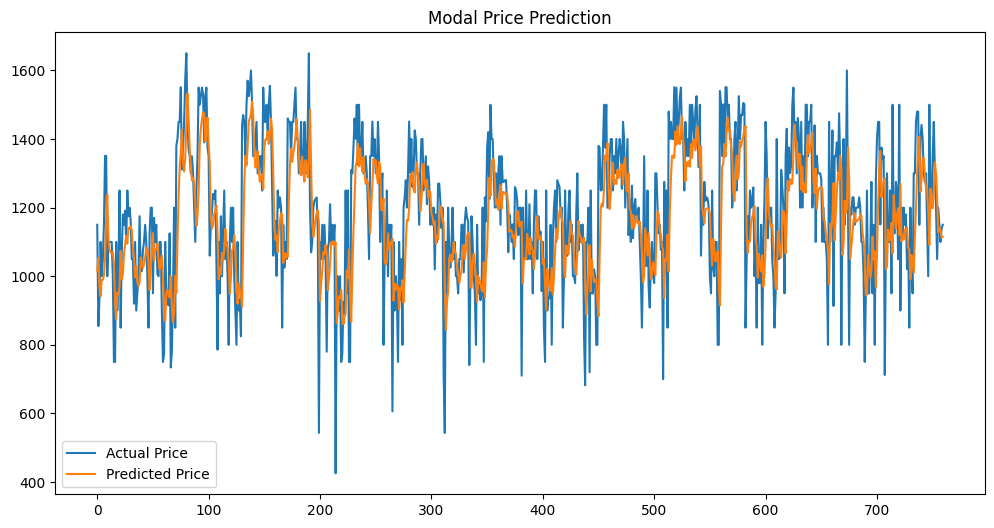

In [100]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.legend()
plt.title("Modal Price Prediction")
plt.show()

In [101]:
last_sequence = scaled_price[-30:]

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(30):

    pred = model.predict(current_sequence.reshape(1,30,1))

    future_predictions.append(pred[0][0])

    current_sequence = np.append(current_sequence[1:], pred)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━

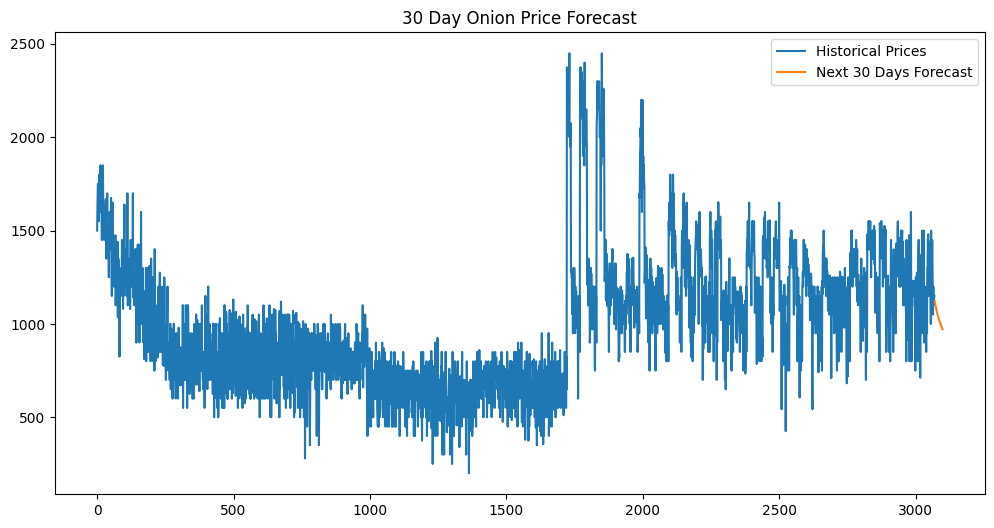

In [102]:
plt.figure(figsize=(12,6))

plt.plot(price.values, label="Historical Prices")

future_dates = pd.date_range(start=df['date'].iloc[-1], periods=31, freq='D')[1:]

plt.plot(
    range(len(price), len(price)+30),
    future_predictions,
    label="Next 30 Days Forecast"
)

plt.legend()
plt.title("30 Day Onion Price Forecast")
plt.show()

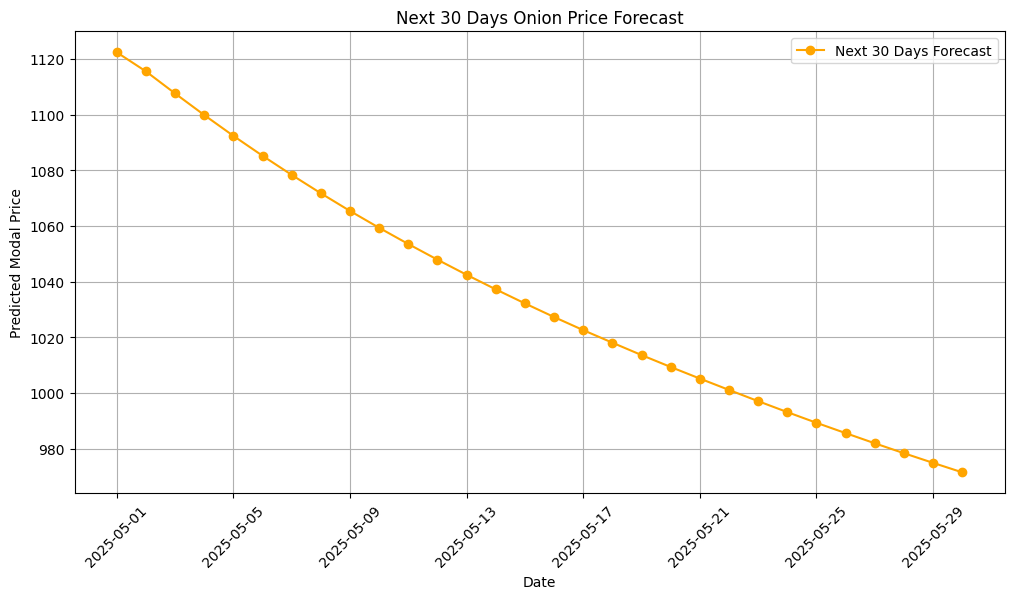

In [103]:
plt.figure(figsize=(12,6))

# Create future date range
future_dates = pd.date_range(start=df['date'].iloc[-1], periods=31, freq='D')[1:]

# Plot predictions
plt.plot(future_dates, future_predictions, marker='o', color='orange', label="Next 30 Days Forecast")

plt.xlabel("Date")
plt.ylabel("Predicted Modal Price")
plt.title("Next 30 Days Onion Price Forecast")

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# inverse scale (if MinMaxScaler used)
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train)
y_test_actual = scaler.inverse_transform(y_test)

# metrics
mae = mean_absolute_error(y_test_actual, test_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
r2 = r2_score(y_test_actual, test_pred)
mape = mean_absolute_percentage_error(y_test_actual, test_pred)

accuracy = 100 - (mape * 100)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)
print("Accuracy:", accuracy, "%")

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAE: 124.22070164409436
RMSE: 164.45417665209334
R2: 0.34521191413167374
MAPE: 0.11230777961179678
Accuracy: 88.76922203882032 %


<Figure size 1200x600 with 0 Axes>

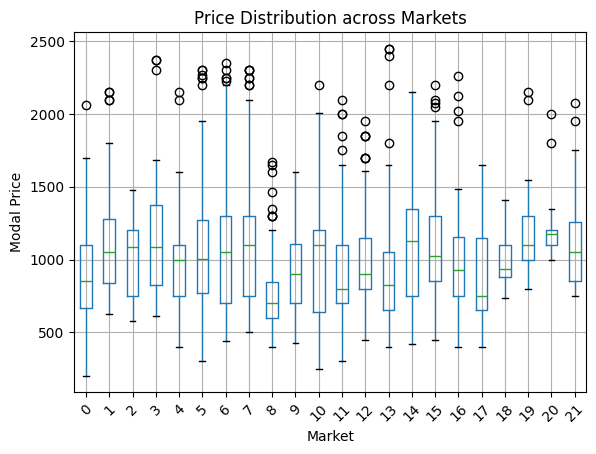

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df.boxplot(column='Modal_Price', by='Market')

plt.title('Price Distribution across Markets')
plt.suptitle('')
plt.xlabel('Market')
plt.ylabel('Modal Price')

plt.xticks(rotation=45)
plt.show()

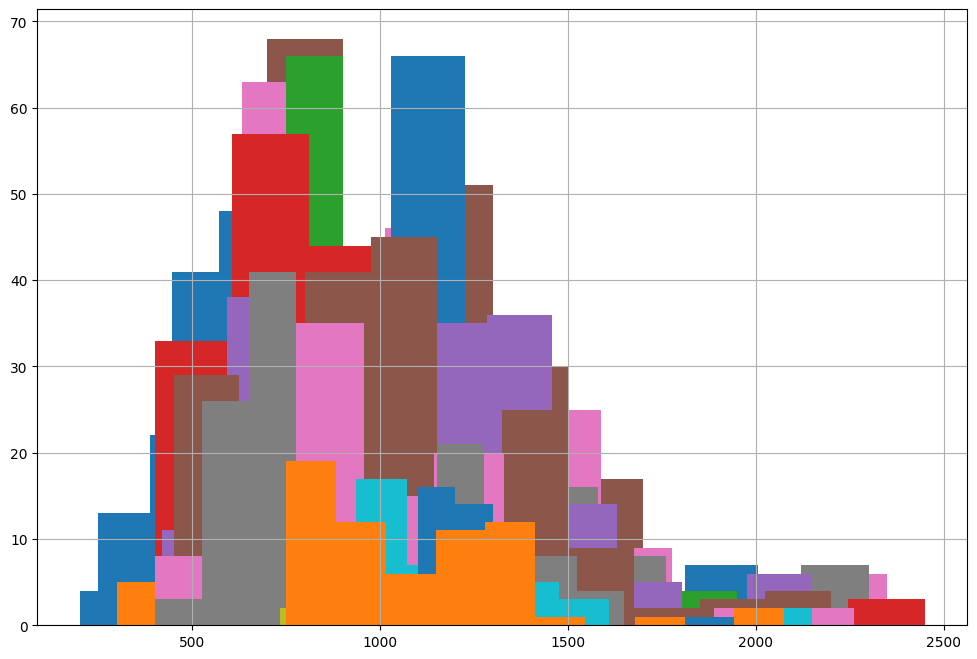

In [106]:
df.groupby('Market')['Modal_Price'].hist(figsize=(12,8))
plt.show()

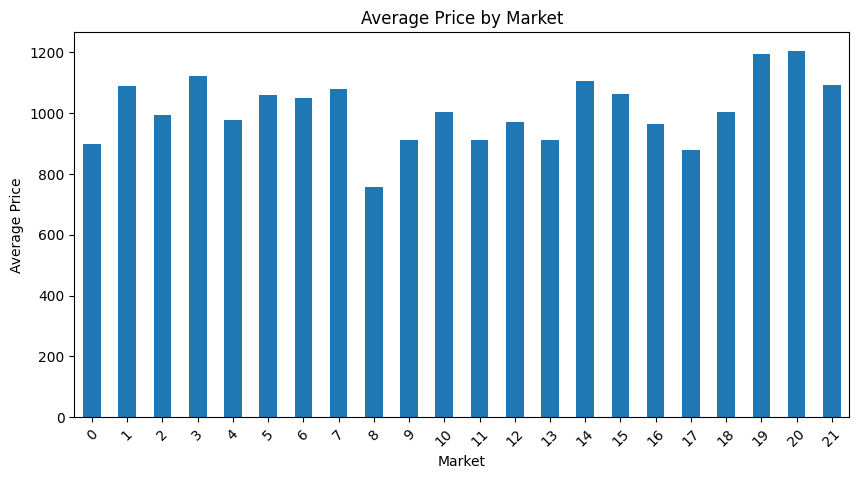

In [107]:
avg_price = df.groupby('Market')['Modal_Price'].mean()

avg_price.plot(kind='bar', figsize=(10,5))
plt.ylabel('Average Price')
plt.title('Average Price by Market')
plt.xticks(rotation=45)
plt.show()

In [108]:
#market vs price

In [109]:
features = [
    'Modal_Price',
    'Market',
    'T2M','WS10M','PS',
    'Modal_Price_lag_1','Modal_Price_lag_7','Modal_Price_lag_14'
]

In [110]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

In [111]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled)):
    X.append(scaled[i-sequence_length:i])
    y.append(scaled[i][0])  # Modal_Price index = 0

X = np.array(X)
y = np.array(y)

In [112]:
train_size = int(len(X)*0.75)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [114]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0206 - val_loss: 0.0077
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0095 - val_loss: 0.0064
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0084 - val_loss: 0.0057
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0078 - val_loss: 0.0063
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0073 - val_loss: 0.0054
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0073 - val_loss: 0.0052
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0069 - val_loss: 0.0070
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0073 - val_loss: 0.0051
Epoch 9/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0065 - val_loss: 0.0068
Epoch 10/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0065 - val_loss: 0.0060
Epoch 11/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0067 - val_loss: 0.0053
Epoch 12/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0

In [115]:
markets = df['Market'].unique()

In [116]:
future_predictions = []

future_dates = pd.date_range(
    start=df['date'].iloc[-1] + pd.Timedelta(days=1),
    periods=31,
    freq='D'
)

for market in markets:

    # last sequence for that market
    market_data = df[df['Market'] == market]

    last_seq = scaler.transform(market_data[features])[-30:]

    current_sequence = last_seq.copy()

    for i in range(30):

        pred = model.predict(current_sequence.reshape(1,30,len(features)))

        # create next row
        next_row = current_sequence[-1].copy()
        next_row[0] = pred  # update price

        current_sequence = np.vstack([current_sequence[1:], next_row])

        future_predictions.append([
            future_dates[i],
            market,
            pred[0][0]
        ])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


C:\Users\rahul\AppData\Local\Temp\ipykernel_28076\345072964.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[0] = pred  # update price


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

C:\Users\rahul\AppData\Local\Temp\ipykernel_28076\345072964.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[0] = pred  # update price


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━

...

C:\Users\rahul\AppData\Local\Temp\ipykernel_28076\345072964.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[0] = pred  # update price


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

C:\Users\rahul\AppData\Local\Temp\ipykernel_28076\345072964.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[0] = pred  # update price


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━

ValueError: cannot reshape array of size 88 into shape (1,30,8)

In [ ]:
pred_df = pd.DataFrame(
    future_predictions,
    columns=['date','Market','Predicted_Price']
)

In [ ]:
pred_df['Predicted_Price'] = scaler.inverse_transform(
    np.concatenate([
        pred_df[['Predicted_Price']],
        np.zeros((len(pred_df), len(features)-1))
    ], axis=1)
)[:,0]

In [ ]:
avg_pred = pred_df.groupby('Market')['Predicted_Price'].mean()

avg_pred.plot(kind='bar', figsize=(10,5))

plt.title('Average Predicted Price per Market (Next 30 Days)')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.show()

In [ ]:
#import ,area and yield